# EVALUACIÓN FINAL: PREDICCIÓN DE NATALIDAD SEGÚN FACTORES SOCIOECONÓMICOS

Eres parte de un equipo de investigación en demografía y te han solicitado desarrollar un **modelo basado en redes neuronales** para predecir la **tasa de natalidad** en distintos países. Contarás con un dataset que incluye información socioeconómica como **PIB per cápita**, **acceso a salud**, **nivel educativo**, **tasa de empleo femenino**, **edad promedio de maternidad**, **urbanización**, entre otras.

**Objetivo general**  
Diseñar, entrenar y evaluar una red neuronal para **regresión**, analizando el impacto de diferentes variables en la predicción.


## Objetivos específicos
1. Diseñar y entrenar una red neuronal para resolver un problema de **regresión**.  
2. Aplicar funciones de activación, optimizadores y **técnicas anti-overfitting** (p. ej., *dropout*, L2).  
3. Evaluar y **comparar configuraciones** de la red.  
4. Analizar la **influencia de variables** predictoras y extraer conclusiones sobre patrones socioeconómicos.


In [16]:
# Librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy.stats import shapiro
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline   
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
import tensorflow as tf
import keras
from keras import layers



In [2]:
# Funciones

def tabla(dfx, fmt='fancy_grid', decimals=2, title=None):
    """
    Muestra un DataFrame o Series en formato tabulado con título opcional.
    
    Parámetros:
    dfx : DataFrame o Series
    fmt : str, formato de tabulate (default: 'fancy_grid')
    decimals : int, número de decimales (default: 2)
    title : str, título de la tabla (default: None)
    """
    # Si es Series → convertir a DataFrame
    if isinstance(dfx, pd.Series):
        dfx = dfx.to_frame(name="Valor")

    # Redondear si son datos numéricos
    try:
        dfx = dfx.round(decimals)
    except:
        pass  # ignora si no aplica

    # Imprimir título si existe
    if title:
        print(f"\n {title}\n" + "-" * (len(title) + 2))

    print(tabulate(dfx, headers="keys", tablefmt=fmt))

def make_viridis_palette(k=12, span=(0.15, 0.95)):
    cmap = plt.colormaps.get_cmap('viridis')   # ✅ forma nueva y segura
    return cmap(np.linspace(span[0], span[1], k))


VIRIDIS = make_viridis_palette(k=12)

def boxplot_viridis(
    df, col, n=0, *,
    whis=(5, 95),          # bigotes por percentiles (más robusto que 1.5*IQR si hay colas largas)
    showfliers=False,      # oculta outliers por defecto (puedes poner True)
    log=False,             # escala log opcional
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis, configurable y limpio.
    - df: DataFrame
    - col: nombre de la columna numérica a graficar
    - n: índice para elegir color en la paleta VIRIDIS
    - whis: "1.5" para usar el 1.5*IQR, o "(5,95)" para más robustez 
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]  # color viridis ciclado
    label = col.replace("_", " ")

    plt.figure(figsize=(8, 5))
    plt.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        #showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        plt.xscale("log")
        plt.xlabel(f"{label} (escala log)")
    else:
        plt.xlabel(label)

    plt.title(f"{title_prefix} {label}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.2)
    return ax

def detectar_outliers_iqr(
    df: pd.DataFrame,
    columna: str,
    n,
    graficar: bool = True,
    inplace: bool = False
):
    """
    Detecta y filtra outliers (IQR). Si inplace=True, modifica df en sitio.
    
    Returns:
        outliers (pd.DataFrame): Filas detectadas como outliers.
        df_filtrado (pd.DataFrame): DataFrame sin outliers (o None si inplace=True).
        limites (dict): Q1, Q3, IQR, límites.
    """
        # 1) (Opcional) Gráfico
    if graficar:
        boxplot_viridis(df, columna, n=n, whis=1.5)

    # 2) Cuartiles e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # 3) Límites de Tukey
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    # 4) Máscara de outliers (NaN no cuenta como outlier)
    mask_out = (df[columna] < li) | (df[columna] > ls)

    # 5) Subsets
    outliers = df.loc[mask_out].copy()
    df_filtrado = df.loc[~mask_out].copy()

    # 6) Métricas y salida formateada
    total_validos = df[columna].notna().sum()
    num_out = int(mask_out.sum())
    pct_out = (num_out / total_validos * 100.0) if total_validos > 0 else 0.0

    limites = {"Q1": Q1, "Q3": Q3, "IQR": IQR,
               "limite_inferior": li, "limite_superior": ls}    
    
    # 7) Impresión de resultados
    print(f"Outliers detectados en {columna}: {num_out} ({pct_out:.2f}%)")
    print("Límites:")
    for k, v in limites.items():
        print(f"  {k}: {v:,.2f}")
    print("Tamaño sin outliers:", df_filtrado.shape)

    # 8) In-place o retorno
    if inplace:
        # Modifica el df original en el caller usando índices (sin reasignar la variable local)
        df.drop(df.index[mask_out], inplace=True)
        return outliers, None, limites
    else:
        return outliers, df_filtrado, limites
    

# ========= Utilidad: Shapiro con manejo de errores =========
def shapiro_safe(x):
    """
    Ejecuta Shapiro-Wilk ignorando NaN y maneja casos con pocos datos o constantes.
    Retorna (stat, pvalue, msg).
    """
    x = pd.Series(x).dropna().values
    if len(x) < 3:
        return np.nan, np.nan, "muestra insuficiente (<3)"
    # Shapiro requiere que no sean todos iguales
    if np.allclose(x, x[0]):
        return np.nan, np.nan, "valores constantes"
    try:
        stat, pval = shapiro(x)
        return stat, pval, None
    except Exception as e:
        return np.nan, np.nan, f"error: {e}"


# ========= 1) HISTOGRAMA + KDE =========
def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")

    return ax


# ========= 2) QQ-PLOT (con p-value de Shapiro opcional) =========
def plot_qq(df, col, ax=None, *, n=0, show_pvalue=True, alpha=0.05):
    """
    QQ-plot contra normal. Si show_pvalue=True, calcula Shapiro y lo muestra en el título.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    # statsmodels dibuja sus propios puntos; ajustamos línea 45
    sm.qqplot(serie, ax=ax, fit=True, line="45", markerfacecolor=c, markeredgecolor="black", alpha=0.7)
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles muestrales")

    title = col.replace("_"," ")
    if show_pvalue:
        _, pval, err = shapiro_safe(serie)
        if err is None and not np.isnan(pval):
            normal_msg = "no normal" if pval < alpha else "no se descarta normalidad"
            title = f"{title}\nShapiro p={pval:.3f} ({normal_msg})"
        else:
            title = f"{title}\nShapiro: {err}"
    ax.set_title(title, weight="bold", fontsize=12)

    return ax


# ========= 3) BOXPLOT VIRIDIS (horizontal) =========
def boxplot_viridis(
    df, col, ax=None, n=0, *,
    whis=(5, 95),
    showfliers=False,
    log=False,
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis.
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]
    label = col.replace("_", " ")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    ax.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        ax.set_xscale("log")
        ax.set_xlabel(f"{label} (escala log)")
    else:
        ax.set_xlabel(label)

    ax.set_yticks([])
    ax.set_title(f"{title_prefix} {label}", fontsize=12, weight="bold")
    return ax


# ========= 4) FUNCIÓN MAESTRA: los 3 gráficos en una sola imagen =========
def triple_plot(df, col, *, n=0, bins='sturges', alpha=0.05, whis=(5,95), showfliers=False, log=False):
    """
    Dibuja en una figura: Histograma+KDE | QQ-plot | Boxplot viridis.
    Reutiliza las funciones anteriores.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    plot_hist_kde(df, col, ax=axs[0], bins=bins, n=n)
    plot_qq(df, col, ax=axs[1], n=n, show_pvalue=True, alpha=alpha)
    boxplot_viridis(df, col, ax=axs[2], n=n, whis=whis, showfliers=showfliers, log=log)

    fig.suptitle(f"Distribución de '{col}'", fontsize=14, weight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

## 1. Carga y exploración de datos (1 punto)
- Carga el dataset con información de países:  
  - PIB per cápita  
  - Acceso a servicios de salud (% población)  
  - Nivel educativo promedio  
  - Tasa de empleo femenino  
  - Edad promedio de maternidad  
  - Índice de urbanización  
  - **Tasa de natalidad** (*variable objetivo*)  
- Analiza las **correlaciones** entre variables y visualiza su **distribución**.


In [3]:
# Carga de dataset

df=pd.read_csv("dataset_natalidad.csv",
               index_col='País'
               )


 Primeras 5 filas
------------------
╒════════╤══════════════════╤════════════════╤═══════════════════╤════════════════════════╤═══════════════════╤════════════════╤══════════════════╕
│ País   │   PIB_per_capita │   Acceso_Salud │   Nivel_Educativo │   Tasa_Empleo_Femenino │   Edad_Maternidad │   Urbanizacion │   Tasa_Natalidad │
╞════════╪══════════════════╪════════════════╪═══════════════════╪════════════════════════╪═══════════════════╪════════════════╪══════════════════╡
│ País_1 │          25599.7 │          51.57 │             14.63 │                  32.58 │             21.55 │          71.89 │            38.61 │
├────────┼──────────────────┼────────────────┼───────────────────┼────────────────────────┼───────────────────┼────────────────┼──────────────────┤
│ País_2 │          57289.3 │          81.82 │              6.26 │                  56.57 │             33.54 │          62.17 │            19.21 │
├────────┼──────────────────┼────────────────┼───────────────────┼────────

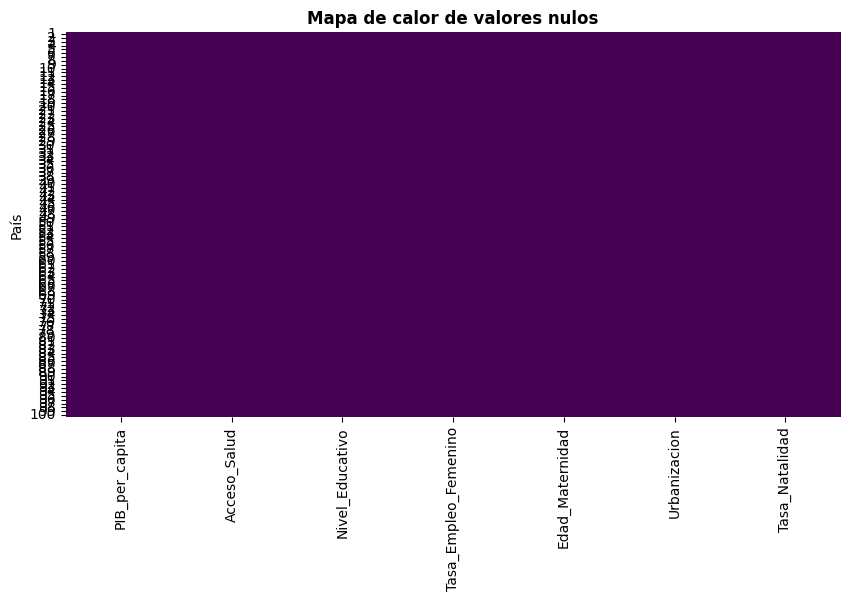

In [8]:
# Exploración inicial

tabla(df.head(5),title="Primeras 5 filas")

print(f"Información inicial del data set:")

df.columns= df.columns.str.replace(" ", "") # Cambio de nombres de columnas
df.index=df.index.str.replace('País_','')
tabla(df.info())

print("\n Dimensiones del DataFrame:", df.shape)

# Deteccion de duplicados
print(f'Número de duplicados: {df.duplicated().sum()}')

# Detección de valores nulos
tabla(df.isnull().sum(), title=" Valores nulos:")

tabla(df.describe(),title=" Estadísticas descriptivas:")

# Visualización nulos

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=True,
            color=sns.color_palette("viridis")[3])
plt.title("Mapa de calor de valores nulos", fontsize=12, fontweight="bold")
plt.show()


 DataFrame numérica
--------------------
╒════════╤══════════════════╤════════════════╤═══════════════════╤════════════════════════╤═══════════════════╤════════════════╤══════════════════╕
│   País │   PIB_per_capita │   Acceso_Salud │   Nivel_Educativo │   Tasa_Empleo_Femenino │   Edad_Maternidad │   Urbanizacion │   Tasa_Natalidad │
╞════════╪══════════════════╪════════════════╪═══════════════════╪════════════════════════╪═══════════════════╪════════════════╪══════════════════╡
│      1 │          25599.7 │          51.57 │             14.63 │                  32.58 │             21.55 │          71.89 │            38.61 │
├────────┼──────────────────┼────────────────┼───────────────────┼────────────────────────┼───────────────────┼────────────────┼──────────────────┤
│      2 │          57289.3 │          81.82 │              6.26 │                  56.57 │             33.54 │          62.17 │            19.21 │
├────────┼──────────────────┼────────────────┼───────────────────┼────

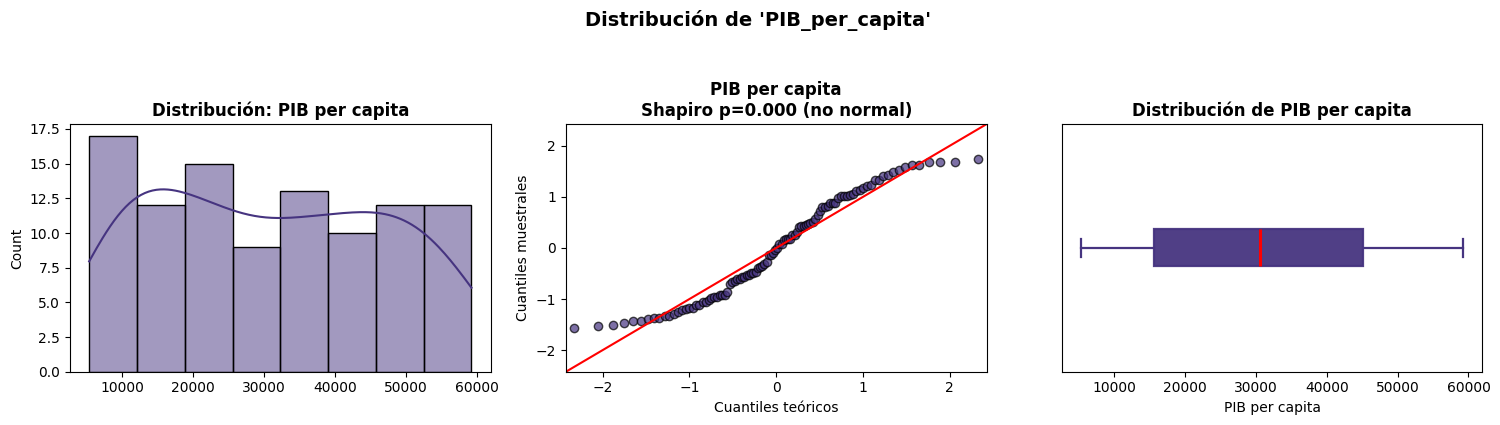

Outliers detectados en Acceso_Salud: 0 (0.00%)
Límites:
  Q1: 62.10
  Q3: 88.31
  IQR: 26.21
  limite_inferior: 22.79
  limite_superior: 127.62
Tamaño sin outliers: (100, 7)


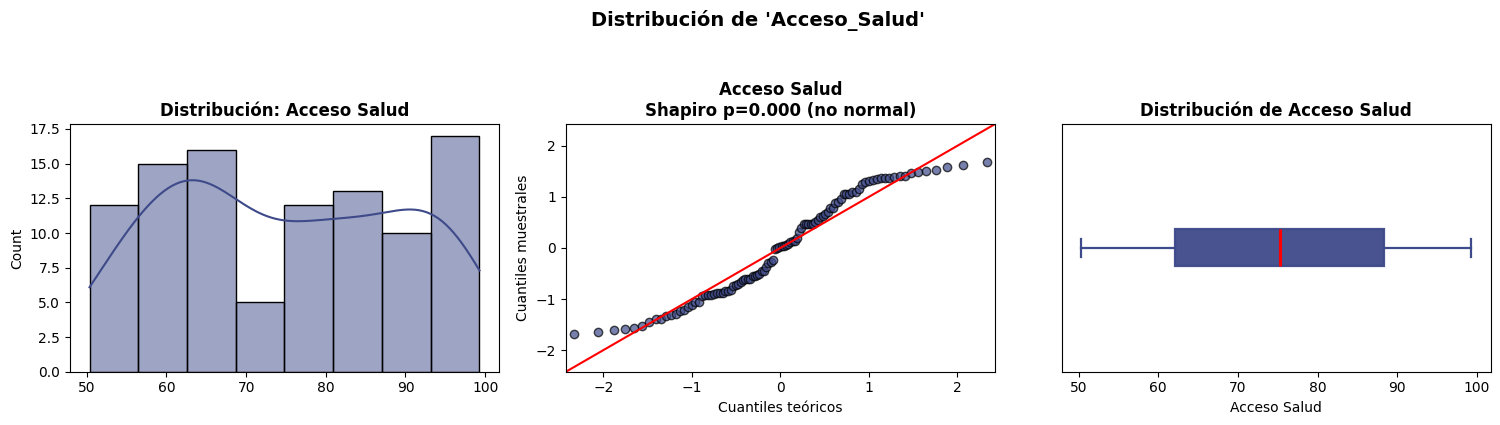

Outliers detectados en Nivel_Educativo: 0 (0.00%)
Límites:
  Q1: 9.15
  Q3: 16.29
  IQR: 7.13
  limite_inferior: -1.55
  limite_superior: 26.98
Tamaño sin outliers: (100, 7)


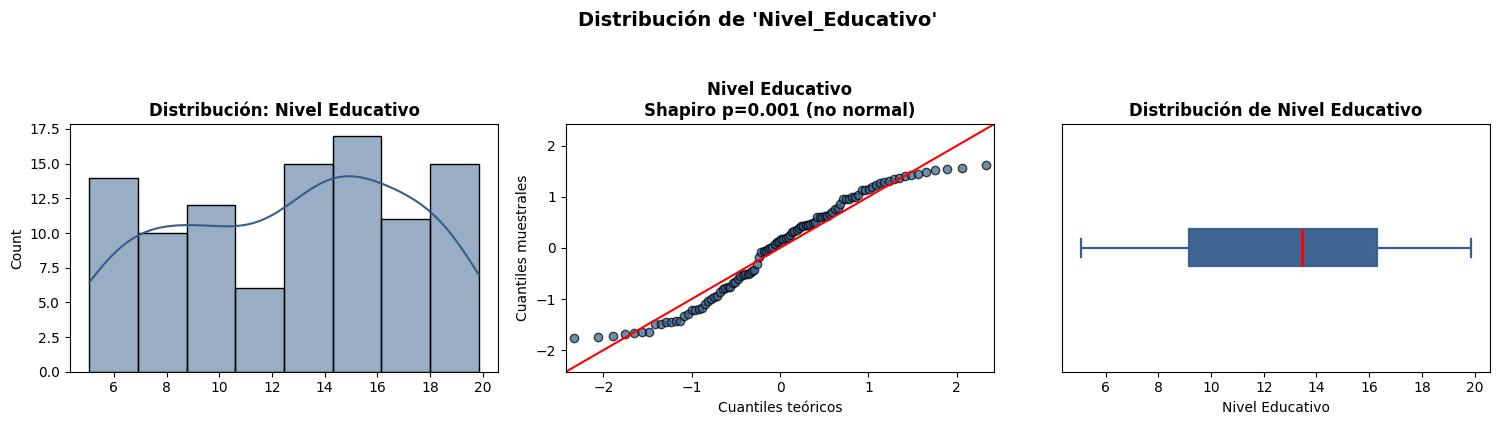

Outliers detectados en Tasa_Empleo_Femenino: 0 (0.00%)
Límites:
  Q1: 42.48
  Q3: 66.79
  IQR: 24.31
  limite_inferior: 6.02
  limite_superior: 103.25
Tamaño sin outliers: (100, 7)


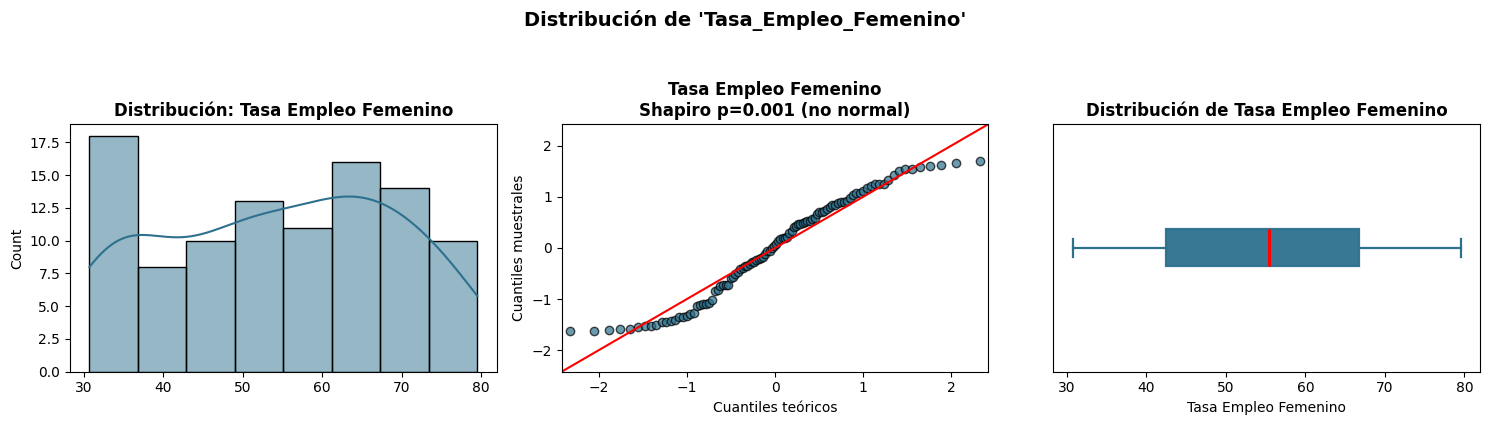

Outliers detectados en Edad_Maternidad: 0 (0.00%)
Límites:
  Q1: 23.96
  Q3: 31.95
  IQR: 7.99
  limite_inferior: 11.97
  limite_superior: 43.94
Tamaño sin outliers: (100, 7)


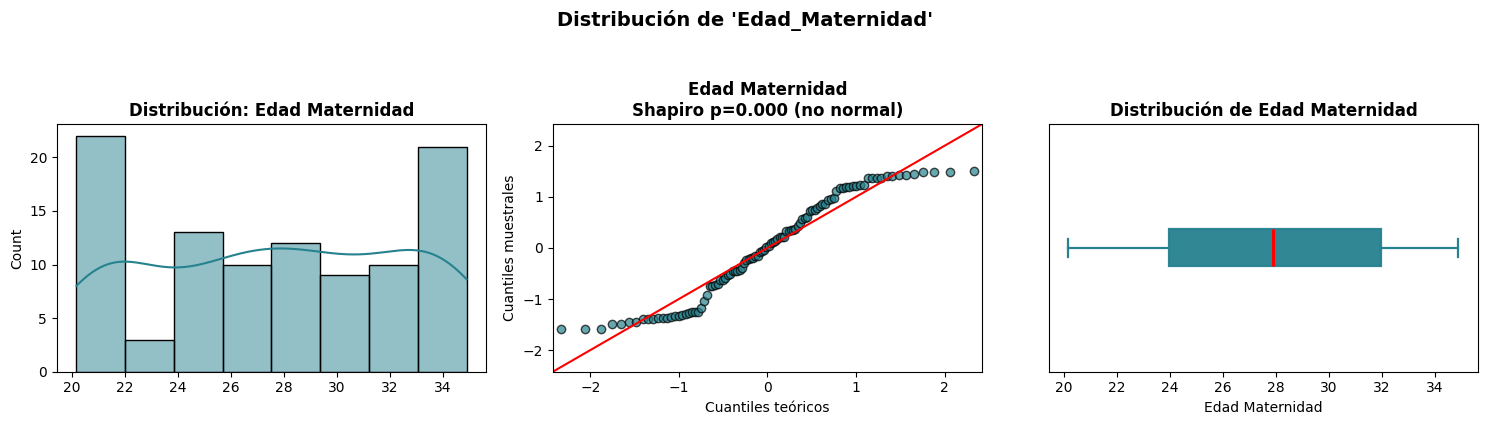

Outliers detectados en Urbanizacion: 0 (0.00%)
Límites:
  Q1: 45.33
  Q3: 78.67
  IQR: 33.34
  limite_inferior: -4.67
  limite_superior: 128.67
Tamaño sin outliers: (100, 7)


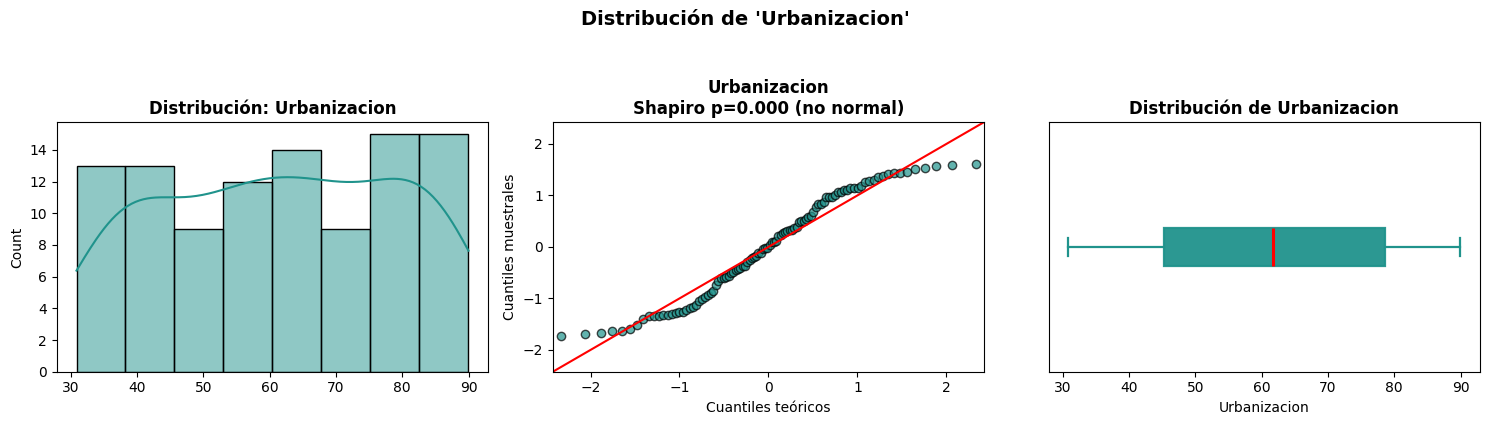

Outliers detectados en Tasa_Natalidad: 0 (0.00%)
Límites:
  Q1: 26.90
  Q3: 39.92
  IQR: 13.03
  limite_inferior: 7.36
  limite_superior: 59.46
Tamaño sin outliers: (100, 7)


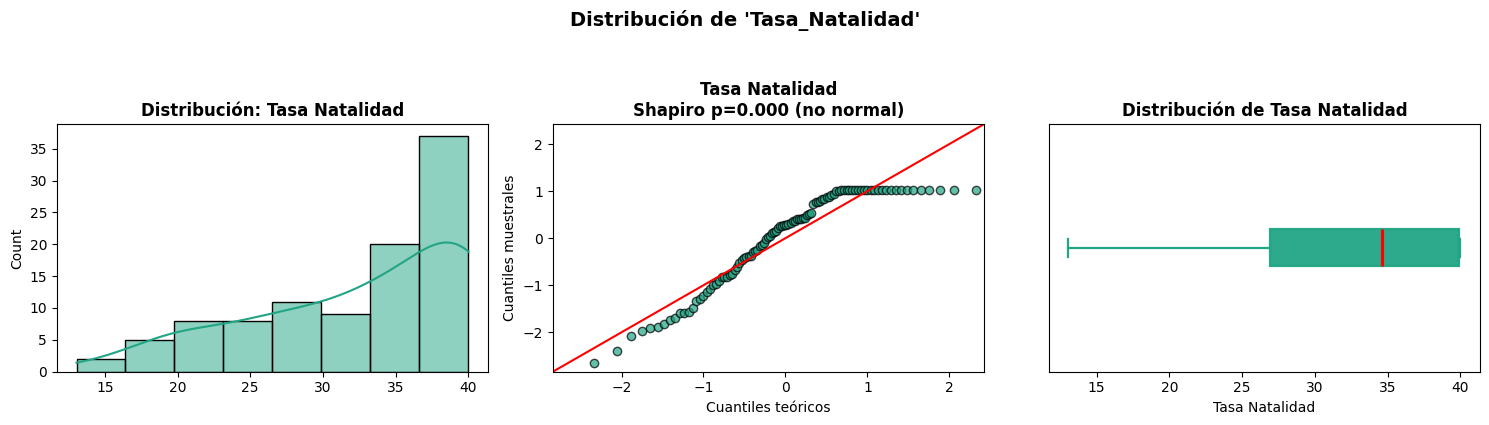

In [9]:
# Detección de valores atípicos
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
df_numerica=df[columnas_numericas]
tabla(df_numerica.head(5),title="DataFrame numérica")
n=0
for col in columnas_numericas:
    detectar_outliers_iqr(df,col,graficar=False,n=n)
    triple_plot(df, col, n=n, bins='sturges', alpha=0.05, whis=1.95, showfliers=False, log=False)
    n+=1

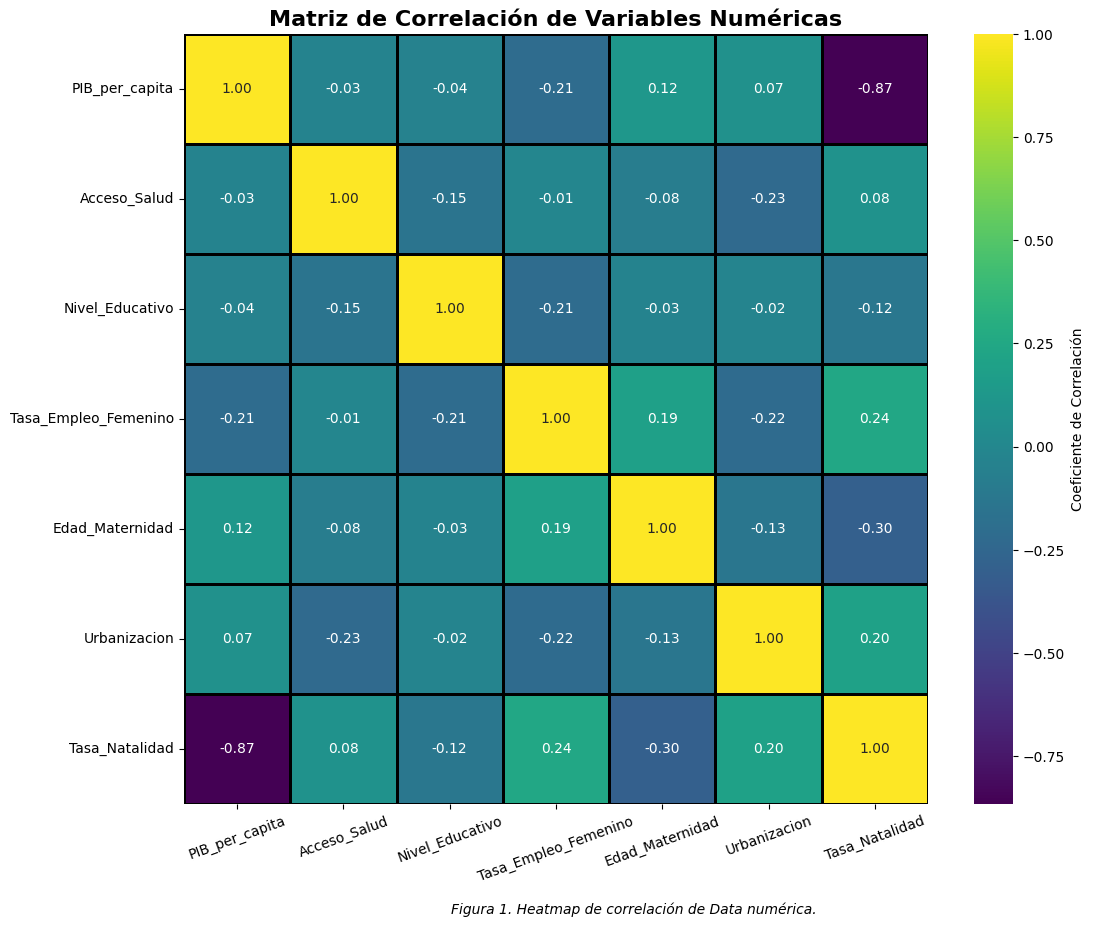

In [10]:
# Matriz de Correlación

plt.figure(figsize=(12, 10)) # Ajusta el tamaño del gráfico
sns.heatmap(df_numerica.corr(),
            annot=True,
            cmap='viridis', # Cambiamos el mapa de colores
            fmt=".2f",
            linewidths=1,   # Mayor grosor de líneas
            linecolor='black', # Color de las líneas
            cbar_kws={'label': 'Coeficiente de Correlación'}) # Etiqueta de la barra de color
plt.title('Matriz de Correlación de Variables Numéricas',
           fontsize=16,
           fontweight="bold") # Tamaño del título
plt.xticks(fontsize=10,rotation=20) # Tamaño de las etiquetas del eje X
plt.yticks(fontsize=10, rotation=0) # Tamaño de las etiquetas del eje Y y rotación
# 🔹 Agregar un caption debajo del gráfico
plt.figtext(0.5,0 , "Figura 1. Heatmap de correlación de Data numérica.", 
            wrap=True, ha="center", fontsize=10, style='italic')
plt.show()

# Análisis
De todas las columnas numéricas, se puede decir con certeza que no hay alguna que tienda a la distribución normal.

Respecto a las correlaciones entre la tasa de la natalidad y las demás variables, la que más correlacionada está es el pib per capita del País, pero 
tiene un efecto negativo. de las 6 variables, tenemos una correlacion positiva con tres, siendo:
 Tasa de empleo femenino,  urbanización y acceso a la salud en 
orden descendente con respecto a la correlación. tiene lógica que la urbanizacíon implique mayor natalidad. al igual que el acceso a la salud, aunque el empleo 
femenino es un tanto contraintuitivo, ya que las mujeres están trabajando más, pero no  están teniendo más hijos. 

Mientras que de manera negativa, en orden ascendente es nivel educativo, edad maternidad, y el Pib per capita del país. el ivel educativo afecta negativamente 
porque las mujeres que mantienen sus estudios, no compatibiliza con la crianza de los hijos. La edad, afecta de manera negativa por el riesgo que implica la 
maternidad tardía. El impacto negativo del PIB per cápita no tiene mucha lógica, ya que se podría inferir que mientras más dinero tenga el país mejor será el bienestar de las personas, implicando una mayor tasa de natalidad.

In [12]:
# Definición de variables
#  
# Variable objetivo (Y)
Y= df_numerica['Tasa_Natalidad']
# Variables predictoras (X) = todas menos "Tasa_Natalidad"
X= df_numerica.copy().drop(columns=["Tasa_Natalidad"])

lenx=len(X.columns)
print(f'Cantidad de variables predictoras: {lenx}')


Cantidad de variables predictoras: 6


## 2. Diseño y entrenamiento del modelo (5 puntos)
- Diseña una **red neuronal** con:  
  - Capa de entrada con tantas neuronas como variables predictoras.  
  - **≥ 2 capas ocultas** con activaciones adecuadas.  
  - Capa de salida con **1 neurona** (predicción de tasa de natalidad).  

In [ ]:
# Red. neuronal 


- Prueba distintas **funciones de activación** y evalúa su impacto.  
- Utiliza **optimizadores** adecuados y experimenta con diferentes *learning rates*.  
- Aplica **regularización** (*dropout* o L2) para evitar sobreajuste.  
- Entrena el modelo con una **función de pérdida** apropiada para regresión.


## 3. Evaluación y optimización del modelo (3 puntos)
- Evalúa el desempeño con el **conjunto de prueba**.  
- Ajusta **hiperparámetros** para mejorar el rendimiento.  
- Analiza el **impacto de cada variable** en la predicción.  
- Realiza **predicciones** y compáralas con datos reales.


## 4. Análisis de resultados y reflexión final (1 punto)
- Indica qué **variables** fueron más influyentes.  
- Relaciona resultados con **tendencias demográficas**.  
- Propón **mejoras** para futuras versiones del modelo.


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Descarga el **dataset** proporcionado.  
- Incluye **código comentado** con tu implementación.  
- **Comprime** tu proyecto (`.zip`/`.rar`).  
- Adjunta un documento con **reflexiones analíticas**.  
- Sube tu entrega a la **plataforma**.



# **Pregunta 2 — Modelado con *pipelines* y reporte de métricas (Regresión)**

En esta sección se resuelve la **Pregunta 2** tomando como base el dataset entregado (`dataset_natalidad.csv`) y manteniendo intacto lo desarrollado en la **Pregunta 1**.
Se implementa un flujo reproducible con **scikit‑learn Pipeline**, que incluye:
- Selección de variables numéricas.
- Separación **train/test** con `random_state=42`.
- Modelos de regresión: **Regresión Lineal**, **Ridge** (con *GridSearchCV*), y **RandomForestRegressor**.
- Función `metrics_report` para **MAE, MSE, RMSE y R²**.
- Gráficos de diagnóstico (residuales y `y_real` vs `y_pred`) usando **matplotlib** con **cmap 'viridis'**.


In [ ]:

# === Pregunta 2: Setup e Importaciones ===
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# Utilidad: reporte de métricas
def metrics_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}).round(4)

# Cargar dataset
df = pd.read_csv("/mnt/data/dataset_natalidad.csv")

# Intentar detectar la columna objetivo comúnmente usada
candidate_targets = ["Tasa_Natalidad", "tasa_natalidad", "target", "y"]
target = None
for c in candidate_targets:
    if c in df.columns:
        target = c
        break
if target is None:
    # Si no existe, levantamos una pista clara al usuario dentro del notebook
    raise ValueError("No se encontró la columna objetivo. Asegúrate de que exista, por ejemplo 'Tasa_Natalidad'. Columnas disponibles: "
                     + ", ".join(df.columns.astype(str)))

# Selección de columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target not in num_cols:
    raise ValueError(f"La columna objetivo '{target}' no es numérica. Tipos: {df.dtypes[target]}")

X = df[num_cols].drop(columns=[target])
y = df[target]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocesamiento numérico: imputación + escalado
numeric_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pre, X.columns.tolist())
])
print(f"Shape X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")


In [ ]:

# === Definición y entrenamiento de modelos ===

results = {}

# 1) Regresión Lineal
pipe_lin = Pipeline(steps=[
    ("pre", preprocess),
    ("model", LinearRegression())
])
pipe_lin.fit(X_train, y_train)
pred_lin = pipe_lin.predict(X_test)
results["LinearRegression"] = metrics_report(y_test, pred_lin)

# 2) Ridge + GridSearchCV
pipe_ridge = Pipeline(steps=[
    ("pre", preprocess),
    ("model", Ridge(random_state=42))
])

param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_search = GridSearchCV(
    pipe_ridge, param_grid=param_grid, cv=cv, scoring="r2", n_jobs=-1
)
ridge_search.fit(X_train, y_train)
pred_ridge = ridge_search.predict(X_test)
results["Ridge(best)"] = metrics_report(y_test, pred_ridge)

# 3) RandomForestRegressor
pipe_rf = Pipeline(steps=[
    ("pre", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])
pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)
results["RandomForest"] = metrics_report(y_test, pred_rf)

report_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
report_df


In [ ]:

# === Gráficos de diagnóstico con viridis ===
# NOTA: conforme a las restricciones, usamos matplotlib y colormap 'viridis'.

def plot_ytrue_vs_ypred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    sc = plt.scatter(y_true, y_pred, c=np.abs(y_true - y_pred), cmap='viridis', alpha=0.9)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], linestyle="--")
    plt.xlabel("y real")
    plt.ylabel("y predicho")
    plt.title(title)
    cb = plt.colorbar(sc)
    cb.set_label("|error|")
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    resid = y_true - y_pred
    plt.figure(figsize=(7,4))
    plt.scatter(y_pred, resid, alpha=0.9, cmap='viridis')
    plt.axhline(0, linestyle='--')
    plt.xlabel("y predicho")
    plt.ylabel("residual (y - ŷ)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_ytrue_vs_ypred(y_test, pred_lin, "LinearRegression: y_real vs y_pred (viridis)")
plot_residuals(y_test, pred_lin, "LinearRegression: Residuales")

plot_ytrue_vs_ypred(y_test, pred_ridge, "Ridge (best): y_real vs y_pred (viridis)")
plot_residuals(y_test, pred_ridge, "Ridge (best): Residuales")

plot_ytrue_vs_ypred(y_test, pred_rf, "RandomForest: y_real vs y_pred (viridis)")
plot_residuals(y_test, pred_rf, "RandomForest: Residuales")



### Conclusiones de la Pregunta 2
- Se compararon **tres modelos** de regresión con un **pipeline** común de preprocesamiento.
- El **reporte de métricas** muestra el desempeño en el *test set* en términos de **MAE, MSE, RMSE y R²**.
- Los **gráficos de diagnóstico** ayudan a identificar patrones de error (no linealidades, heterocedasticidad, *outliers*).
- Si se requiere, se puede extender con **selección de características**, **ingeniería de variables** y **búsqueda bayesiana** de hiperparámetros.
